In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from datetime import datetime, timedelta
import pandas as pd
import h5py

In [7]:
# file = "/datasets/hdf5_data_uv_temp/test/2019.h5"
file = "/datasets/hdf5_data_uv_temp/train/1980.h5"
# file = "/datasets/hdf5_data_uvsp_swh_mwp_1/train/1989.h5"

In [8]:
with h5py.File(file, 'r') as hdf:
	keys = list(hdf.keys())
	print("Keys:", keys)
	for key in keys:
		data = hdf[key][:]
		print(f"data for key '{key}' has shape {data.shape}")
	lat = hdf['latitude'][:]
	long = hdf['longitude'][:]
	fields = hdf['fields'][:]
	time = hdf['time'][:]


Keys: ['channel', 'fields', 'latitude', 'longitude', 'time']
data for key 'channel' has shape (2,)
data for key 'fields' has shape (8784, 2, 721, 1440)
data for key 'latitude' has shape (721,)
data for key 'longitude' has shape (1440,)
data for key 'time' has shape (8784,)


In [6]:
time_pd = pd.to_datetime(time, unit='h', origin='1900-01-01')
time_pd

DatetimeIndex(['1989-01-01 00:00:00', '1989-01-01 01:00:00',
               '1989-01-01 02:00:00', '1989-01-01 03:00:00',
               '1989-01-01 04:00:00', '1989-01-01 05:00:00',
               '1989-01-01 06:00:00', '1989-01-01 07:00:00',
               '1989-01-01 08:00:00', '1989-01-01 09:00:00',
               ...
               '1989-12-31 14:00:00', '1989-12-31 15:00:00',
               '1989-12-31 16:00:00', '1989-12-31 17:00:00',
               '1989-12-31 18:00:00', '1989-12-31 19:00:00',
               '1989-12-31 20:00:00', '1989-12-31 21:00:00',
               '1989-12-31 22:00:00', '1989-12-31 23:00:00'],
              dtype='datetime64[ns]', length=8760, freq=None)

In [7]:
# ind = time_pd.get_loc("2015-09-27T04:00:00")
ind = time_pd.get_loc("1989-01-01T04:00:00")
ind

4

In [8]:
X,Y = np.meshgrid(long, lat)


In [9]:
nan_count = np.isnan(fields[0,3,:,:]).sum().item()
nan_count

12254

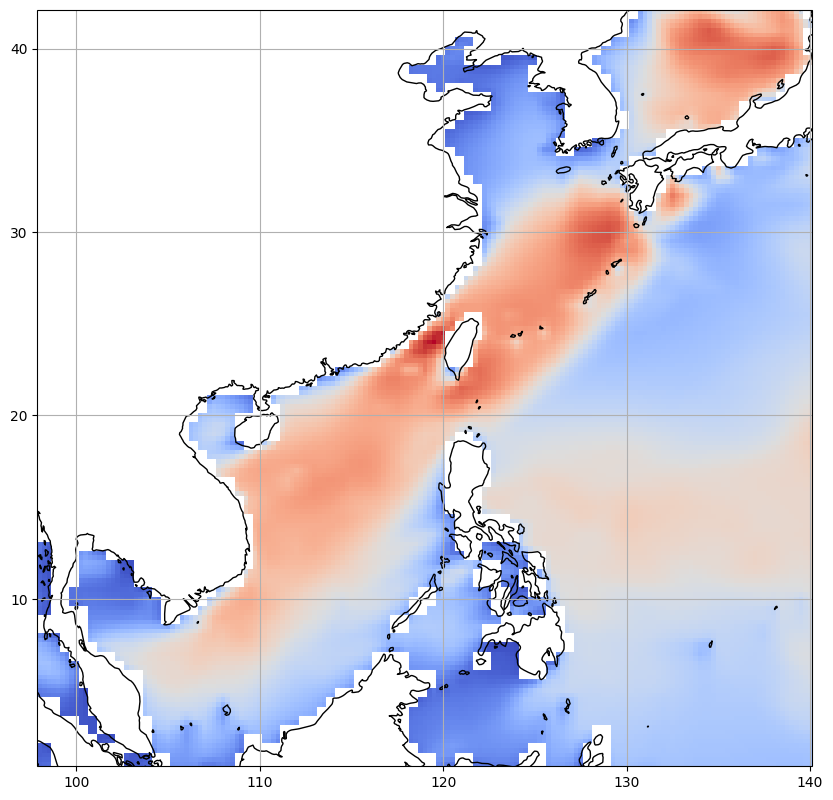

In [12]:
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution="50m")
ax.set_xticks(range(-180, 181, 10), crs=ccrs.PlateCarree())
ax.set_yticks(range(-90, 91, 10), crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=False)

ax.pcolormesh(X, Y, fields[ind, 3, :, :], cmap='coolwarm')
